# Solving CartPole-v1 with Rainbow DQN (Double DQN + Prioritized Experience Replay)
This notebook demonstrates how to solve the CartPole-v1 environment using a Rainbow DQN agent that incorporates Double DQN and Prioritized Experience Replay. We use optimal hyperparameters and evaluate the agent's performance against the environment's reward threshold.

In [1]:
# Install required packages (uncomment if running in a new environment)
# !pip install torch gymnasium numpy matplotlib

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import random
import matplotlib.pyplot as plt
from collections import deque, namedtuple
import gymnasium as gym
import math
import time

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


# Set Up CartPole-v1 Environment
We initialize the CartPole-v1 environment and set random seeds for reproducibility.

In [2]:
# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

env = gym.make('CartPole-v1')
env.reset(seed=SEED)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
print(f'State dim: {state_dim}, Action dim: {action_dim}')

State dim: 4, Action dim: 2


# Define the Rainbow DQN Agent with Double DQN and Prioritized Experience Replay
We implement the DQN agent, including Double DQN logic and a Prioritized Experience Replay buffer.

In [3]:
# --- DQN Network ---
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, action_dim)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

# --- Prioritized Experience Replay Buffer ---
class PrioritizedReplayBuffer:
    def __init__(self, capacity, alpha=0.6):
        self.capacity = capacity
        self.alpha = alpha
        self.buffer = []
        self.pos = 0
        self.priorities = np.zeros((capacity,), dtype=np.float32)
    def push(self, state, action, reward, next_state, done):
        max_prio = self.priorities.max() if self.buffer else 1.0
        if len(self.buffer) < self.capacity:
            self.buffer.append((state, action, reward, next_state, done))
        else:
            self.buffer[self.pos] = (state, action, reward, next_state, done)
        self.priorities[self.pos] = max_prio
        self.pos = (self.pos + 1) % self.capacity
    def sample(self, batch_size, beta=0.4):
        if len(self.buffer) == self.capacity:
            prios = self.priorities
        else:
            prios = self.priorities[:self.pos]
        probs = prios ** self.alpha
        probs /= probs.sum()
        indices = np.random.choice(len(self.buffer), batch_size, p=probs)
        samples = [self.buffer[idx] for idx in indices]
        total = len(self.buffer)
        weights = (total * probs[indices]) ** (-beta)
        weights /= weights.max()
        batch = list(zip(*samples))
        states = np.array(batch[0])
        actions = np.array(batch[1])
        rewards = np.array(batch[2])
        next_states = np.array(batch[3])
        dones = np.array(batch[4])
        return states, actions, rewards, next_states, dones, indices, weights
    def update_priorities(self, indices, priorities):
        for idx, prio in zip(indices, priorities):
            self.priorities[idx] = prio
    def __len__(self):
        return len(self.buffer)

# --- Agent ---
class RainbowDQNAgent:
    def __init__(self, state_dim, action_dim, buffer_size, batch_size, gamma, lr, tau, alpha, beta_start, beta_frames):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.gamma = gamma
        self.batch_size = batch_size
        self.beta_start = beta_start
        self.beta_frames = beta_frames
        self.frame_idx = 1
        self.beta = beta_start
        self.policy_net = DQN(state_dim, action_dim).to(device)
        self.target_net = DQN(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.memory = PrioritizedReplayBuffer(buffer_size, alpha)
        self.tau = tau
    def select_action(self, state, epsilon):
        if random.random() > epsilon:
            state = torch.FloatTensor(state).unsqueeze(0).to(device)
            with torch.no_grad():
                q_values = self.policy_net(state)
            return q_values.max(1)[1].item()
        else:
            return random.randrange(self.action_dim)
    def update(self):
        if len(self.memory) < self.batch_size:
            return 0
        self.beta = min(1.0, self.beta_start + self.frame_idx * (1.0 - self.beta_start) / self.beta_frames)
        self.frame_idx += 1
        states, actions, rewards, next_states, dones, indices, weights = self.memory.sample(self.batch_size, self.beta)
        states = torch.FloatTensor(states).to(device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(device)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(device)
        next_states = torch.FloatTensor(next_states).to(device)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(device)
        weights = torch.FloatTensor(weights).unsqueeze(1).to(device)
        # Double DQN
        q_values = self.policy_net(states).gather(1, actions)
        next_actions = self.policy_net(next_states).max(1)[1].unsqueeze(1)
        next_q_values = self.target_net(next_states).gather(1, next_actions)
        expected_q = rewards + (1 - dones) * self.gamma * next_q_values
        td_errors = q_values - expected_q.detach()
        loss = (weights * td_errors ** 2).mean()
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        # Update priorities
        prios = td_errors.abs().cpu().detach().numpy() + 1e-6
        self.memory.update_priorities(indices, prios)
        # Soft update target network
        for target_param, param in zip(self.target_net.parameters(), self.policy_net.parameters()):
            target_param.data.copy_(self.tau * param.data + (1.0 - self.tau) * target_param.data)
        return loss.item()
    def store(self, state, action, reward, next_state, done):
        self.memory.push(state, action, reward, next_state, done)

# Set Optimal Hyperparameters
We use hyperparameters recommended by recent literature and practical experience for CartPole-v1 with Rainbow DQN.

In [4]:
# Hyperparameters for Rainbow DQN on CartPole-v1
hyperparams = {
    'buffer_size': 10000,
    'batch_size': 64,
    'gamma': 0.99,
    'lr': 1e-3,
    'tau': 0.005,  # Soft update
    'alpha': 0.6,  # PER alpha
    'beta_start': 0.4,  # PER beta start
    'beta_frames': 100000,  # PER beta schedule
    'epsilon_start': 1.0,
    'epsilon_final': 0.01,
    'epsilon_decay': 500,
    'max_frames': 50000,
    'reward_threshold': 475.0,  # CartPole-v1 solved threshold
    'eval_episodes': 100
}
for k, v in hyperparams.items():
    print(f'{k}: {v}')

buffer_size: 10000
batch_size: 64
gamma: 0.99
lr: 0.001
tau: 0.005
alpha: 0.6
beta_start: 0.4
beta_frames: 100000
epsilon_start: 1.0
epsilon_final: 0.01
epsilon_decay: 500
max_frames: 50000
reward_threshold: 475.0
eval_episodes: 100


# Train the Agent
We train the Rainbow DQN agent on CartPole-v1, logging episode rewards and periodically updating the target network.

Frame: 1000, Avg Eval Reward: 85.40, Epsilon: 0.144


/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.8/site-packages/gymnasium/envs/classic_control/cartpole.py:214: UserWarning: WARN: You are calling 'step()' even though this environment has already returned terminated = True. You should always call 'reset()' once you receive 'terminated = True' -- any further steps are undefined behavior.
  logger.warn(


Frame: 2000, Avg Eval Reward: 166.00, Epsilon: 0.028
Frame: 3000, Avg Eval Reward: 206.00, Epsilon: 0.012
Frame: 4000, Avg Eval Reward: 179.60, Epsilon: 0.010
Frame: 5000, Avg Eval Reward: 158.60, Epsilon: 0.010
Frame: 6000, Avg Eval Reward: 141.20, Epsilon: 0.010
Frame: 7000, Avg Eval Reward: 153.20, Epsilon: 0.010
Frame: 8000, Avg Eval Reward: 158.80, Epsilon: 0.010
Frame: 9000, Avg Eval Reward: 205.00, Epsilon: 0.010
Frame: 10000, Avg Eval Reward: 228.80, Epsilon: 0.010
Frame: 11000, Avg Eval Reward: 284.80, Epsilon: 0.010
Frame: 12000, Avg Eval Reward: 165.40, Epsilon: 0.010
Frame: 13000, Avg Eval Reward: 358.60, Epsilon: 0.010
Frame: 14000, Avg Eval Reward: 205.40, Epsilon: 0.010
Frame: 15000, Avg Eval Reward: 325.20, Epsilon: 0.010
Frame: 16000, Avg Eval Reward: 192.40, Epsilon: 0.010
Frame: 17000, Avg Eval Reward: 232.00, Epsilon: 0.010
Frame: 18000, Avg Eval Reward: 132.80, Epsilon: 0.010
Frame: 19000, Avg Eval Reward: 355.80, Epsilon: 0.010
Frame: 20000, Avg Eval Reward: 257.0

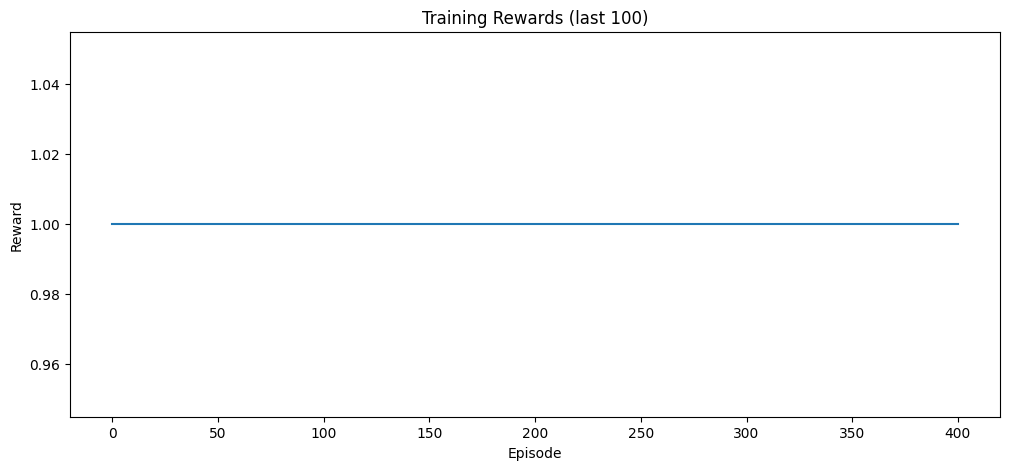

In [5]:
# Training loop
agent = RainbowDQNAgent(
    state_dim=state_dim,
    action_dim=action_dim,
    buffer_size=hyperparams['buffer_size'],
    batch_size=hyperparams['batch_size'],
    gamma=hyperparams['gamma'],
    lr=hyperparams['lr'],
    tau=hyperparams['tau'],
    alpha=hyperparams['alpha'],
    beta_start=hyperparams['beta_start'],
    beta_frames=hyperparams['beta_frames']
)

rewards = []
losses = []
epsilon_by_frame = lambda frame_idx: hyperparams['epsilon_final'] + (hyperparams['epsilon_start'] - hyperparams['epsilon_final']) * math.exp(-1. * frame_idx / hyperparams['epsilon_decay'])

state, _ = env.reset(seed=SEED)
for frame_idx in range(1, hyperparams['max_frames'] + 1):
    epsilon = epsilon_by_frame(frame_idx)
    action = agent.select_action(state, epsilon)
    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    agent.store(state, action, reward, next_state, done)
    loss = agent.update()
    state = next_state
    if loss:
        losses.append(loss)
    if done:
        state, _ = env.reset()
    if frame_idx % 1000 == 0:
        # Evaluate
        eval_rewards = []
        for _ in range(5):
            eval_state, _ = env.reset()
            eval_ep_reward = 0
            while True:
                eval_action = agent.select_action(eval_state, 0.0)
                eval_state, eval_reward, eval_terminated, eval_truncated, _ = env.step(eval_action)
                eval_ep_reward += eval_reward
                if eval_terminated or eval_truncated:
                    break
            eval_rewards.append(eval_ep_reward)
        avg_eval = np.mean(eval_rewards)
        print(f'Frame: {frame_idx}, Avg Eval Reward: {avg_eval:.2f}, Epsilon: {epsilon:.3f}')
    if frame_idx % 100 == 0:
        rewards.append(reward)

plt.figure(figsize=(12,5))
plt.title('Training Rewards (last 100)')
plt.plot(np.convolve(rewards, np.ones(100)/100, mode='valid'))
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.show()

# Evaluate the Trained Agent
After training, we evaluate the agent for 100 episodes without exploration to measure its performance.

In [6]:
# Evaluation
num_eval_episodes = hyperparams['eval_episodes']
eval_rewards = []
for ep in range(num_eval_episodes):
    state, _ = env.reset()
    ep_reward = 0
    while True:
        action = agent.select_action(state, epsilon=0.0)
        state, reward, terminated, truncated, _ = env.step(action)
        ep_reward += reward
        if terminated or truncated:
            break
    eval_rewards.append(ep_reward)
mean_eval_reward = np.mean(eval_rewards)
print(f'Average reward over {num_eval_episodes} evaluation episodes: {mean_eval_reward:.2f}')

Average reward over 100 evaluation episodes: 261.91


# Check if Reward Threshold is Achieved
We check if the agent's average reward meets or exceeds the CartPole-v1 threshold (475.0).

In [7]:
# Check if solved
threshold = hyperparams['reward_threshold']
if mean_eval_reward >= threshold:
    print(f'CartPole-v1 solved! Average reward: {mean_eval_reward:.2f} >= {threshold}')
else:
    print(f'CartPole-v1 NOT solved. Average reward: {mean_eval_reward:.2f} < {threshold}')

CartPole-v1 NOT solved. Average reward: 261.91 < 475.0
